# TabPFN for Predicting AC Power Flow Solutions under New Loading Conditions

**Training set**: Known bus properties + solved AC PF results from *N* different loading conditions (tunable).  
**Test set**: Known bus properties for a new (unseen) loading condition — **all PF solution quantities are unknown**.  
**Task**: Given only bus identity, structural properties, and the load scale, predict the full PF solution (`vm_pu`, `va_degree`, `p_mw`, `q_mvar`) at every bus.

This is essentially learning the AC power flow mapping: *known grid info + loading condition → PF solution*.

In [160]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Solve AC PF under a given load scaling factor

In [161]:
import copy

def solve_pf_at_loading(base_net, load_scale):
    """
    Scale all loads by the given factor, run AC power flow,
    and return a DataFrame with enhanced bus properties + solved PF results.
    Uses features from both before and after solving PF to determine bus roles,
    and includes base-case PF results as reference features.
    """
    net = copy.deepcopy(base_net)
    net.load['p_mw'] = base_net.load['p_mw'] * load_scale
    net.load['q_mvar'] = base_net.load['q_mvar'] * load_scale
    pp.runpp(net)

    # === Known bus properties (available before solving PF) ===
    bus_info = net.bus[['vn_kv', 'zone']].copy()
    bus_info['bus_idx'] = bus_info.index

    # Aggregate nominal load per bus (after scaling)
    load_per_bus = net.load.groupby('bus').agg(
        nominal_p_mw=('p_mw', 'sum'),
        nominal_q_mvar=('q_mvar', 'sum')
    )
    bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)

    # Aggregate gen setpoints per bus
    gen_per_bus = net.gen.groupby('bus').agg(
        gen_p_mw=('p_mw', 'sum'),
        gen_vm_pu=('vm_pu', 'mean')
    )
    bus_info = bus_info.join(gen_per_bus, how='left').fillna(0.0)

    # --- External grid (slack bus) info ---
    ext_grid_buses = set(net.ext_grid['bus'].values)
    bus_info['is_slack'] = bus_info.index.isin(ext_grid_buses).astype(int)
    ext_grid_vm = net.ext_grid.groupby('bus').agg(ext_grid_vm_pu=('vm_pu', 'mean'))
    bus_info = bus_info.join(ext_grid_vm, how='left').fillna(0.0)

    # --- Shunt info ---
    if len(net.shunt) > 0:
        shunt_per_bus = net.shunt.groupby('bus').agg(
            shunt_p_mw=('p_mw', 'sum'),
            shunt_q_mvar=('q_mvar', 'sum')
        )
        bus_info = bus_info.join(shunt_per_bus, how='left').fillna(0.0)
    else:
        bus_info['shunt_p_mw'] = 0.0
        bus_info['shunt_q_mvar'] = 0.0
    bus_info['has_shunt'] = ((bus_info['shunt_p_mw'] != 0) | (bus_info['shunt_q_mvar'] != 0)).astype(int)

    # --- Topological features ---
    from_counts = net.line['from_bus'].value_counts()
    to_counts = net.line['to_bus'].value_counts()
    line_degree = from_counts.add(to_counts, fill_value=0)
    if len(net.trafo) > 0:
        hv_counts = net.trafo['hv_bus'].value_counts()
        lv_counts = net.trafo['lv_bus'].value_counts()
        trafo_degree = hv_counts.add(lv_counts, fill_value=0)
        total_degree = line_degree.add(trafo_degree, fill_value=0)
    else:
        total_degree = line_degree
    bus_info['n_connections'] = total_degree.reindex(bus_info.index, fill_value=0).astype(int)

    # --- Enhanced has_gen / has_load using BOTH pre-PF and post-PF info ---
    # Pre-PF: explicit gen/ext_grid entries
    gen_buses_pre = set(net.gen['bus'].values) | ext_grid_buses
    # Post-PF (base case): net injection p_mw < 0 indicates generation
    gen_buses_post = set(base_net.res_bus[base_net.res_bus['p_mw'] < -0.01].index)
    bus_info['has_gen'] = bus_info.index.isin(gen_buses_pre | gen_buses_post).astype(int)

    # Pre-PF: explicit load entries
    load_buses_pre = set(net.load['bus'].values)
    # Post-PF (base case): net injection p_mw > 0 indicates consumption
    load_buses_post = set(base_net.res_bus[base_net.res_bus['p_mw'] > 0.01].index)
    bus_info['has_load'] = bus_info.index.isin(load_buses_pre | load_buses_post).astype(int)

    # --- Bus type (PQ=0, PV=1, Slack=2) ---
    bus_type_arr = np.zeros(len(bus_info), dtype=int)
    bus_type_arr[bus_info['has_gen'].values == 1] = 1
    bus_type_arr[bus_info['is_slack'].values == 1] = 2
    bus_info['bus_type'] = bus_type_arr

    # === Base case PF results as reference features (solved once, always available) ===
    bus_info['base_vm_pu'] = base_net.res_bus['vm_pu'].values
    bus_info['base_va_degree'] = base_net.res_bus['va_degree'].values
    bus_info['base_p_mw'] = base_net.res_bus['p_mw'].values
    bus_info['base_q_mvar'] = base_net.res_bus['q_mvar'].values

    # Base case gen reactive power per bus (from res_gen)
    if len(base_net.res_gen) > 0:
        base_gen_q = pd.DataFrame({
            'bus': base_net.gen['bus'].values,
            'base_gen_q_mvar': base_net.res_gen['q_mvar'].values
        }).groupby('bus').agg(base_gen_q_mvar=('base_gen_q_mvar', 'sum'))
        bus_info = bus_info.join(base_gen_q, how='left')
        bus_info['base_gen_q_mvar'] = bus_info['base_gen_q_mvar'].fillna(0.0)
    else:
        bus_info['base_gen_q_mvar'] = 0.0

    # Base case load results per bus (from res_load)
    if len(base_net.res_load) > 0:
        base_load_res = pd.DataFrame({
            'bus': base_net.load['bus'].values,
            'base_load_p_mw': base_net.res_load['p_mw'].values,
            'base_load_q_mvar': base_net.res_load['q_mvar'].values
        }).groupby('bus').agg(
            base_load_p_mw=('base_load_p_mw', 'sum'),
            base_load_q_mvar=('base_load_q_mvar', 'sum')
        )
        bus_info = bus_info.join(base_load_res, how='left')
        bus_info['base_load_p_mw'] = bus_info['base_load_p_mw'].fillna(0.0)
        bus_info['base_load_q_mvar'] = bus_info['base_load_q_mvar'].fillna(0.0)
    else:
        bus_info['base_load_p_mw'] = 0.0
        bus_info['base_load_q_mvar'] = 0.0

    bus_info['load_scale'] = load_scale

    # === Solved PF results (targets) ===
    res = net.res_bus[['vm_pu', 'va_degree', 'p_mw', 'q_mvar']].copy()

    row = pd.concat([bus_info.reset_index(drop=True), res.reset_index(drop=True)], axis=1)
    return row

## Load the base grid

In [162]:
net_base = pn.case118()
net_base

This pandapower network includes the following parameter tables:
   - bus (118 elements)
   - load (99 elements)
   - gen (53 elements)
   - shunt (14 elements)
   - ext_grid (1 element)
   - line (173 elements)
   - trafo (13 elements)
   - poly_cost (54 elements)

In [163]:
pp.runpp(net_base)

In [164]:
net_base.res_gen

,p_mw,q_mvar,va_degree,vm_pu
0,0.0,-3.104083,10.941479,0.955
1,0.0,-15.009349,15.542785,0.998
2,0.0,15.929753,13.260600,0.990
3,0.0,63.138495,21.009208,1.015
4,450.0,-51.042152,35.844223,1.050
5,85.0,91.291877,12.457681,0.990
6,0.0,7.162620,11.443054,0.970
7,0.0,28.427933,11.749952,0.973
8,0.0,-14.272484,11.283753,0.962
9,0.0,-14.923462,21.094645,0.992


In [165]:
net_base.res_bus.sort_values(by='p_mw', ascending=True).head(10)

,vm_pu,va_degree,p_mw,q_mvar
88,1.005,39.771879,-607.000000,5.903877
68,1.035,30.000000,-514.169694,64.858796
9,1.050,35.844223,-450.000000,51.042152
64,1.005,27.675265,-391.000000,-182.398652
65,1.050,27.519076,-353.000000,19.940603
79,1.040,29.016158,-347.000000,-120.105954
25,1.015,29.932064,-314.000000,-10.129625
24,1.050,28.153045,-220.000000,-50.049144
99,1.017,28.083341,-215.000000,-77.548966
60,0.995,24.080178,-160.000000,40.394611


In [166]:
net_base.res_load.sort_values(by='p_mw', ascending=False).head(10)

,p_mw,q_mvar
50,277.0,113.0
96,184.0,0.0
71,163.0,42.0
64,130.0,26.0
45,113.0,32.0
33,96.0,23.0
11,90.0,30.0
40,87.0,30.0
47,84.0,18.0
51,78.0,3.0


## Define loading conditions

Tune `n_train_conditions` to control how many loading scenarios are used for training.  
Scaling factors are evenly spaced in [scale_min, scale_max]. The test scale should fall within this range but not coincide with a training point.

In [167]:
# === Tunable parameters ===
n_train_conditions = 5   # number of training loading conditions (tune this!)
scale_min = 0.60          # lower bound of load scaling range
scale_max = 1.20          # upper bound of load scaling range
test_scale = 1.17        # unseen test loading condition
# ===========================


train_scales = np.linspace(scale_min, scale_max, n_train_conditions).tolist()
print(f"Test load scale:      {test_scale}")

# Remove any training scale that is too close to the test scaleprint(f"Training load scales: [{train_scales[0]:.4f}, ..., {train_scales[-1]:.4f}]")

train_scales = [s for s in train_scales if abs(s - test_scale) > 1e-6]
print(f"Number of training conditions: {len(train_scales)}")


Test load scale:      1.17
Number of training conditions: 5


## Solve AC PF for all loading conditions

In [168]:
train_frames = []
for s in train_scales:
    res = solve_pf_at_loading(net_base, load_scale=s)
    train_frames.append(res)
    print(f"Solved PF for load_scale = {s:.2f}  ({len(res)} buses)")

train_df = pd.concat(train_frames, ignore_index=True)
print(f"\nTotal training rows: {len(train_df)}")
train_df.head()

Solved PF for load_scale = 0.60  (118 buses)
Solved PF for load_scale = 0.75  (118 buses)
Solved PF for load_scale = 0.90  (118 buses)
Solved PF for load_scale = 1.05  (118 buses)
Solved PF for load_scale = 1.20  (118 buses)

Total training rows: 590


/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/3802051564.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)
/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/3802051564.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)
/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/3802051564.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and w

,vn_kv,zone,bus_idx,nominal_p_mw,nominal_q_mvar,gen_p_mw,gen_vm_pu,is_slack,ext_grid_vm_pu,shunt_p_mw,...,base_p_mw,base_q_mvar,base_gen_q_mvar,base_load_p_mw,base_load_q_mvar,load_scale,vm_pu,va_degree,p_mw,q_mvar
0,138.0,1.0,0,30.6,16.2,0.0,0.955,0,0.0,0.0,...,51.0,30.104083,-3.104083,51.0,27.0,0.6,0.955000,59.581973,30.6,43.809929
1,138.0,1.0,1,12.0,5.4,0.0,0.000,0,0.0,0.0,...,20.0,9.000000,0.000000,20.0,9.0,0.6,0.973856,59.642084,12.0,5.400000
2,138.0,1.0,2,23.4,6.0,0.0,0.000,0,0.0,0.0,...,39.0,10.000000,0.000000,39.0,10.0,0.6,0.969874,60.022931,23.4,6.000000
3,138.0,1.0,3,23.4,7.2,0.0,0.998,0,0.0,0.0,...,39.0,27.009349,-15.009349,39.0,12.0,0.6,0.998000,62.300402,23.4,30.750470
4,138.0,1.0,4,0.0,0.0,0.0,0.000,0,0.0,0.0,...,0.0,40.158927,0.000000,0.0,0.0,0.6,1.001674,62.597332,0.0,40.134055


In [169]:
test_df = solve_pf_at_loading(net_base, load_scale=test_scale)
print(f"Solved PF for test load_scale = {test_scale:.2f}  ({len(test_df)} buses)")


Solved PF for test load_scale = 1.17  (118 buses)


/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/3802051564.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)


In [170]:
test_df.sort_values(by='p_mw', ascending=True).head(30)

,vn_kv,zone,bus_idx,nominal_p_mw,nominal_q_mvar,gen_p_mw,gen_vm_pu,is_slack,ext_grid_vm_pu,shunt_p_mw,...,base_p_mw,base_q_mvar,base_gen_q_mvar,base_load_p_mw,base_load_q_mvar,load_scale,vm_pu,va_degree,p_mw,q_mvar
68,138.0,1.0,68,0.00,0.00,0.0,0.000,1,1.035,0.0,...,-514.169694,64.858796,0.000000,0.0,0.0,1.17,1.035000,30.000000,-1319.651462,62.915233
88,138.0,1.0,88,0.00,0.00,607.0,1.005,0,0.000,0.0,...,-607.000000,5.903877,-5.903877,0.0,0.0,1.17,1.005000,24.834776,-607.000000,5.725291
9,345.0,1.0,9,0.00,0.00,450.0,1.050,0,0.000,0.0,...,-450.000000,51.042152,-51.042152,0.0,0.0,1.17,1.050000,15.043952,-450.000000,51.042152
64,345.0,1.0,64,0.00,0.00,391.0,1.005,0,0.000,0.0,...,-391.000000,-182.398652,182.398652,0.0,0.0,1.17,1.005000,18.055950,-391.000000,-246.551881
65,138.0,1.0,65,45.63,21.06,392.0,1.050,0,0.000,0.0,...,-353.000000,19.940603,-1.940603,39.0,18.0,1.17,1.050000,16.706808,-346.370000,23.022901
79,138.0,1.0,79,152.10,30.42,477.0,1.040,0,0.000,0.0,...,-347.000000,-120.105954,146.105954,130.0,26.0,1.17,1.040000,19.673323,-324.900000,-135.951727
25,345.0,1.0,25,0.00,0.00,314.0,1.015,0,0.000,0.0,...,-314.000000,-10.129625,10.129625,0.0,0.0,1.17,1.015000,11.109380,-314.000000,-14.424009
24,138.0,1.0,24,0.00,0.00,220.0,1.050,0,0.000,0.0,...,-220.000000,-50.049144,50.049144,0.0,0.0,1.17,1.050000,9.525275,-220.000000,-55.557565
99,138.0,1.0,99,43.29,21.06,252.0,1.017,0,0.000,0.0,...,-215.000000,-77.548966,95.548966,37.0,18.0,1.17,1.017000,13.826122,-208.710000,-94.353749
60,138.0,1.0,60,0.00,0.00,160.0,0.995,0,0.000,0.0,...,-160.000000,40.394611,-40.394611,0.0,0.0,1.17,0.995000,12.425897,-160.000000,35.451279


## Prepare features and targets

**Input features** (known before PF + base-case reference):
- **Bus identity/structure**: `bus_idx`, `vn_kv`, `zone`, `n_connections`, `bus_type`
- **Load/gen setpoints**: `nominal_p_mw`, `nominal_q_mvar`, `gen_p_mw`, `gen_vm_pu`
- **Slack/shunt**: `is_slack`, `ext_grid_vm_pu`, `shunt_p_mw`, `shunt_q_mvar`, `has_shunt`
- **Bus roles (pre+post PF)**: `has_gen`, `has_load`
- **Base-case PF reference**: `base_vm_pu`, `base_va_degree`, `base_p_mw`, `base_q_mvar`, `base_gen_q_mvar`, `base_load_p_mw`, `base_load_q_mvar`
- **Loading condition**: `load_scale`

**Targets** (solved PF results, all unknown for test): `vm_pu`, `va_degree`, `p_mw`, `q_mvar`

We train a separate TabPFN regressor for each target variable.

In [171]:
feature_cols = [
    'bus_idx', 'vn_kv', 'zone',
    'nominal_p_mw', 'nominal_q_mvar',
    'gen_p_mw', 'gen_vm_pu',
    'is_slack', 'ext_grid_vm_pu',
    'shunt_p_mw', 'shunt_q_mvar', 'has_shunt',
    'n_connections',
    'has_gen', 'has_load', 'bus_type',
    'base_vm_pu', 'base_va_degree', 'base_p_mw', 'base_q_mvar',
    'base_gen_q_mvar', 'base_load_p_mw', 'base_load_q_mvar',
    'load_scale'
]
target_cols = ['vm_pu', 'va_degree', 'p_mw', 'q_mvar']

X_train = train_df[feature_cols]
Y_train = train_df[target_cols]

X_test = test_df[feature_cols]
Y_test = test_df[target_cols]  # ground truth (for evaluation only)

print(f"X_train shape: {X_train.shape}  (buses×conditions × features)")
print(f"X_test  shape: {X_test.shape}   (buses × features)")
print(f"\nInput features ({len(feature_cols)}):  {feature_cols}")
print(f"Target columns:  {target_cols}")

X_train shape: (590, 24)  (buses×conditions × features)
X_test  shape: (118, 24)   (buses × features)

Input features (24):  ['bus_idx', 'vn_kv', 'zone', 'nominal_p_mw', 'nominal_q_mvar', 'gen_p_mw', 'gen_vm_pu', 'is_slack', 'ext_grid_vm_pu', 'shunt_p_mw', 'shunt_q_mvar', 'has_shunt', 'n_connections', 'has_gen', 'has_load', 'bus_type', 'base_vm_pu', 'base_va_degree', 'base_p_mw', 'base_q_mvar', 'base_gen_q_mvar', 'base_load_p_mw', 'base_load_q_mvar', 'load_scale']
Target columns:  ['vm_pu', 'va_degree', 'p_mw', 'q_mvar']


## Train one TabPFN regressor per target and predict

Since TabPFN is a single-target regressor, we train 4 models — one for each PF output variable.

In [172]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

for target in target_cols:
    print(f"\n--- Training for target: {target} ---")
    reg = TabPFNRegressor()
    reg.fit(X_train, Y_train[target])
    preds = reg.predict(X_test)

    mse = mean_squared_error(Y_test[target], preds)
    mae = mean_absolute_error(Y_test[target], preds)
    r2 = r2_score(Y_test[target], preds)

    results[target] = {
        'predictions': preds,
        'mse': mse,
        'mae': mae,
        'r2': r2
    }
    print(f"  MSE:  {mse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  R²:   {r2:.6f}")

# Summary table
summary = pd.DataFrame({t: {k: v for k, v in r.items() if k != 'predictions'}
                         for t, r in results.items()}).T
print("\n=== Summary ===")
summary


--- Training for target: vm_pu ---
  MSE:  0.000000
  MAE:  0.000382
  R²:   0.999127

--- Training for target: va_degree ---
  MSE:  3.260070
  MAE:  1.694502
  R²:   0.971507

--- Training for target: p_mw ---
  MSE:  49.318249
  MAE:  0.814055
  R²:   0.998209

--- Training for target: q_mvar ---
  MSE:  5.432509
  MAE:  0.801371
  R²:   0.997060

=== Summary ===


,mse,mae,r2
vm_pu,4.861026e-07,0.000382,0.999127
va_degree,3.260070e+00,1.694502,0.971507
p_mw,4.931825e+01,0.814055,0.998209
q_mvar,5.432509e+00,0.801371,0.997060


## Visualize predictions vs actual for all targets

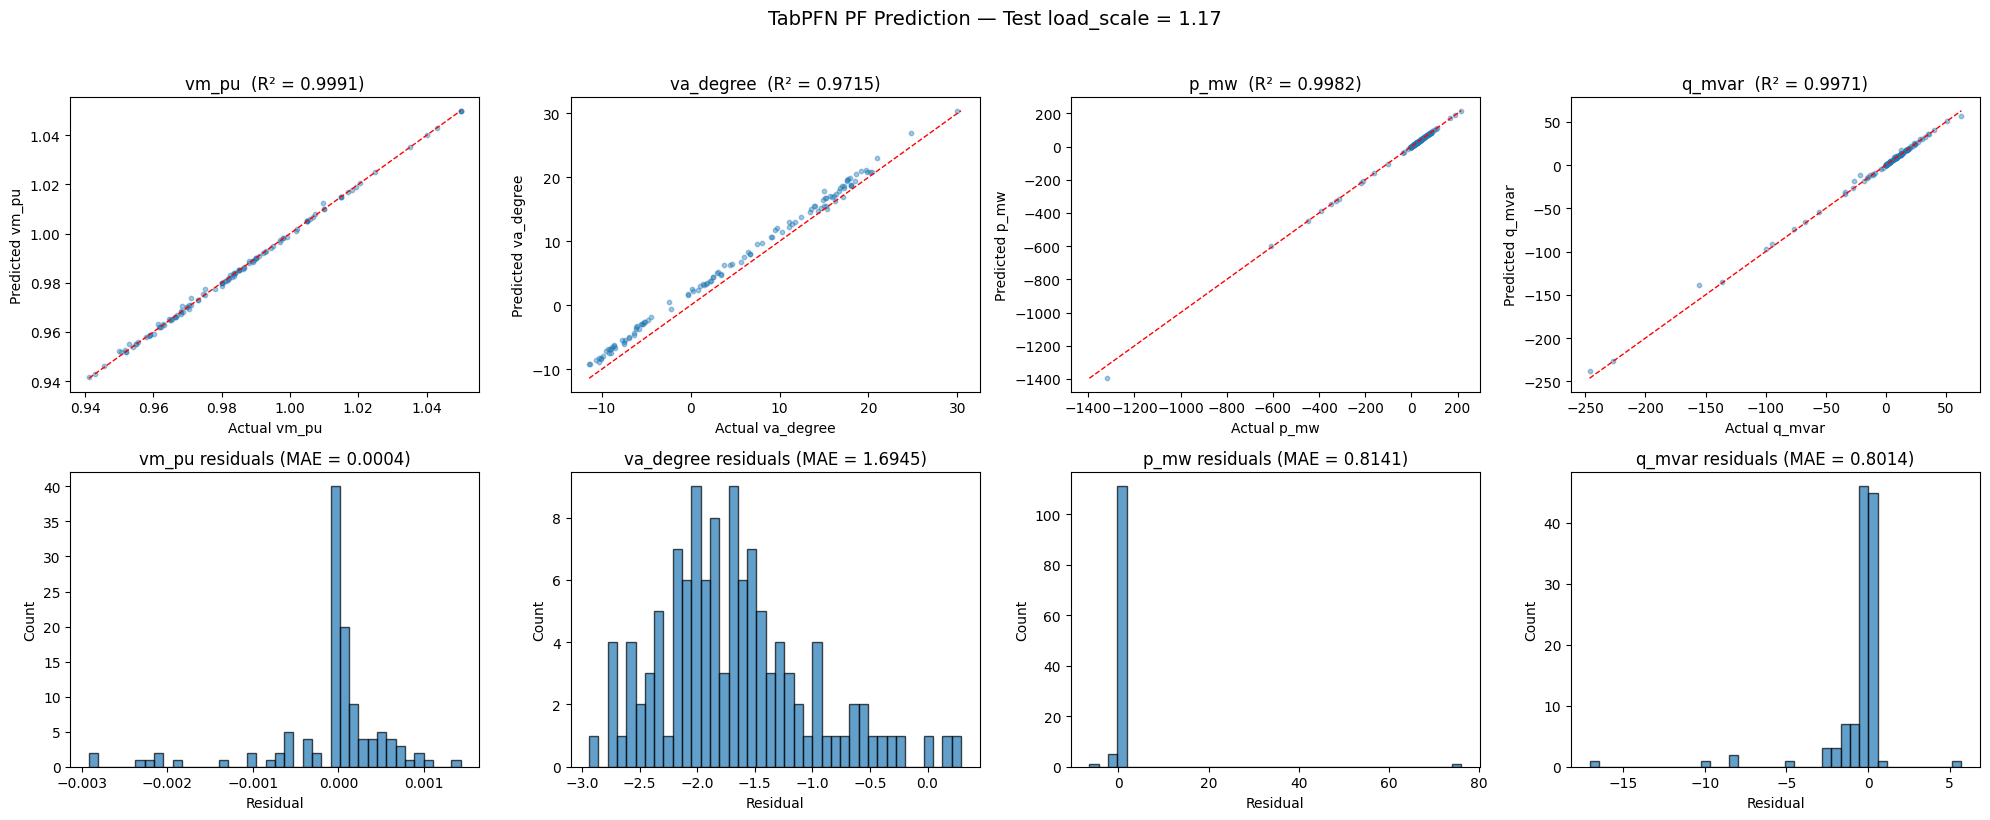

In [173]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, target in enumerate(target_cols):
    actual = Y_test[target].values
    preds = results[target]['predictions']
    r2 = results[target]['r2']
    mae = results[target]['mae']

    # Scatter: predicted vs actual
    ax = axes[0, i]
    ax.scatter(actual, preds, alpha=0.4, s=10)
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel(f'Actual {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target}  (R² = {r2:.4f})')

    # Residual histogram
    ax = axes[1, i]
    residuals = actual - preds
    ax.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{target} residuals (MAE = {mae:.4f})')

plt.suptitle(f'TabPFN PF Prediction — Test load_scale = {test_scale}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Per-bus error analysis — compare predicted vs actual PF solution

In [174]:
error_df = pd.DataFrame({'bus_idx': test_df['bus_idx'].values})

# Add bus role info from enhanced features
error_df['bus_type'] = test_df['bus_type'].values
error_df['is_slack'] = test_df['is_slack'].values
error_df['has_gen'] = test_df['has_gen'].values
error_df['has_load'] = test_df['has_load'].values
error_df['has_shunt'] = test_df['has_shunt'].values
error_df['n_connections'] = test_df['n_connections'].values
error_df['gen_p_mw'] = test_df['gen_p_mw'].values
error_df['nominal_p_mw'] = test_df['nominal_p_mw'].values

# Human-readable bus role
def get_bus_role(row):
    roles = []
    if row['is_slack']:
        roles.append('Slack')
    elif row['has_gen']:
        roles.append('Generator')
    if row['has_load']:
        roles.append('Load')
    if row['has_shunt']:
        roles.append('Shunt')
    if not roles:
        roles.append('Transit')
    return '+'.join(roles)

error_df['role'] = error_df.apply(get_bus_role, axis=1)

for target in target_cols:
    error_df[f'{target}_actual'] = Y_test[target].values
    error_df[f'{target}_pred'] = results[target]['predictions']
    error_df[f'{target}_err'] = np.abs(Y_test[target].values - results[target]['predictions'])

error_df['total_abs_err'] = sum(error_df[f'{t}_err'] for t in target_cols)

print("Top 20 buses with highest total absolute error across all PF quantities:")
error_df.sort_values('total_abs_err', ascending=False).head(20)

Top 20 buses with highest total absolute error across all PF quantities:


,bus_idx,bus_type,is_slack,has_gen,has_load,has_shunt,n_connections,gen_p_mw,nominal_p_mw,role,...,va_degree_actual,va_degree_pred,va_degree_err,p_mw_actual,p_mw_pred,p_mw_err,q_mvar_actual,q_mvar_pred,q_mvar_err,total_abs_err
68,68,2,1,1,0,0,6,0.0,0.00,Slack,...,30.000000,30.403286,0.403286,-1319.651462,-1395.642090,75.990628,62.915233,57.195564,5.719668,82.113645
48,48,1,0,1,1,0,12,204.0,101.79,Generator+Load,...,9.192722,10.716080,1.523358,-102.210000,-102.206100,0.003900,-155.796671,-138.728607,17.068064,18.595372
76,76,1,0,1,1,0,7,0.0,71.37,Generator+Load,...,18.525341,19.392002,0.866661,71.370000,71.235443,0.134557,-21.636655,-11.553322,10.083333,11.084569
64,64,1,0,1,0,0,4,391.0,0.00,Generator,...,18.055950,18.843609,0.787659,-391.000000,-391.181244,0.181244,-246.551881,-238.360672,8.191209,9.160116
88,88,1,0,1,0,0,6,607.0,0.00,Generator,...,24.834776,26.987144,2.152369,-607.000000,-600.554443,6.445557,5.725291,5.601143,0.124148,8.722091
69,69,1,0,1,1,0,5,0.0,77.22,Generator+Load,...,16.206959,16.225029,0.018070,77.220000,77.115517,0.104483,-26.629909,-18.306402,8.323506,8.446084
33,33,1,0,1,1,1,4,0.0,69.03,Generator+Load+Shunt,...,-6.397428,-4.676481,1.720947,69.030000,68.934341,0.095659,12.395586,17.423546,5.027960,6.844594
99,99,1,0,1,1,0,8,252.0,43.29,Generator+Load,...,13.826122,15.518549,1.692427,-208.710000,-209.227951,0.517951,-94.353749,-91.545189,2.808560,5.018951
7,7,1,0,1,1,0,3,0.0,32.76,Generator+Load,...,0.208938,2.509193,2.300255,32.760000,32.922401,0.162401,-76.384362,-74.032745,2.351616,4.814321
11,11,1,0,1,1,0,7,85.0,54.99,Generator+Load,...,-9.459362,-7.207858,2.251504,-30.010000,-30.222912,0.212912,-99.397684,-97.173431,2.224252,4.688720


## Analysis: Prediction Error by Bus Role

Analyze whether prediction errors correlate with a bus's role in the grid (Slack, Generator, Load, Transit, Shunt) to understand *why* certain buses are harder to predict.

In [175]:
# === Mean Absolute Error by Bus Role ===
role_stats = error_df.groupby('role').agg(
    count=('bus_idx', 'count'),
    mean_total_err=('total_abs_err', 'mean'),
    max_total_err=('total_abs_err', 'max'),
    mean_vm_err=('vm_pu_err', 'mean'),
    mean_va_err=('va_degree_err', 'mean'),
    mean_p_err=('p_mw_err', 'mean'),
    mean_q_err=('q_mvar_err', 'mean'),
).sort_values('mean_total_err', ascending=False)

print("=== Mean Absolute Error by Bus Role ===\n")
print(role_stats.to_string())

print("\n\n=== Role Distribution of Top 20 Worst Buses ===\n")
worst_20 = error_df.sort_values('total_abs_err', ascending=False).head(20)
print(worst_20['role'].value_counts().to_string())

=== Mean Absolute Error by Bus Role ===

                      count  mean_total_err  max_total_err  mean_vm_err  mean_va_err  mean_p_err  mean_q_err
role                                                                                                        
Slack                     1       82.113645      82.113645     0.000062     0.403286   75.990628    5.719668
Generator                 8        4.207148       9.160116     0.000030     1.837393    1.036472    1.333252
Generator+Load           39        3.517709      18.595372     0.000026     1.708277    0.144942    1.664464
Generator+Load+Shunt      6        3.410907       6.844594     0.000024     1.596904    0.096931    1.717048
Shunt                     2        2.494523       2.656456     0.000091     2.365299    0.038649    0.090484
Load                     48        1.919755       3.078432     0.000673     1.786248    0.093092    0.039743
Load+Shunt                6        1.615799       2.213142     0.001061     1.366383   

In [176]:
# === Detailed analysis of worst predicted buses ===
worst_10 = error_df.sort_values('total_abs_err', ascending=False).head(10)

print("=== Detailed Analysis of Top 10 Worst Predicted Buses ===\n")
for _, row in worst_10.iterrows():
    bus = int(row['bus_idx'])
    print(f"Bus {bus} | Role: {row['role']} | Connections: {int(row['n_connections'])} | "
          f"Gen P: {row['gen_p_mw']:.1f} MW | Load P: {row['nominal_p_mw']:.1f} MW")
    for t in target_cols:
        actual = row[f'{t}_actual']
        pred = row[f'{t}_pred']
        err = row[f'{t}_err']
        print(f"  {t:12s}: actual={actual:+10.4f}  pred={pred:+10.4f}  err={err:.4f}")
    print()

# Summarize patterns
print("=== Pattern Summary ===")
print(f"Slack buses in worst 10:     {(worst_10['is_slack'] == 1).sum()}")
print(f"Generator buses in worst 10: {((worst_10['has_gen'] == 1) & (worst_10['is_slack'] == 0)).sum()}")
print(f"Load-only buses in worst 10: {((worst_10['has_load'] == 1) & (worst_10['has_gen'] == 0)).sum()}")
print(f"Transit buses in worst 10:   {(worst_10['role'] == 'Transit').sum()}")
print(f"Shunt buses in worst 10:     {(worst_10['has_shunt'] == 1).sum()}")
print(f"\nMean connections (worst 10): {worst_10['n_connections'].mean():.1f}")
print(f"Mean connections (all buses): {error_df['n_connections'].mean():.1f}")

=== Detailed Analysis of Top 10 Worst Predicted Buses ===

Bus 68 | Role: Slack | Connections: 6 | Gen P: 0.0 MW | Load P: 0.0 MW
  vm_pu       : actual=   +1.0350  pred=   +1.0351  err=0.0001
  va_degree   : actual=  +30.0000  pred=  +30.4033  err=0.4033
  p_mw        : actual=-1319.6515  pred=-1395.6421  err=75.9906
  q_mvar      : actual=  +62.9152  pred=  +57.1956  err=5.7197

Bus 48 | Role: Generator+Load | Connections: 12 | Gen P: 204.0 MW | Load P: 101.8 MW
  vm_pu       : actual=   +1.0250  pred=   +1.0249  err=0.0001
  va_degree   : actual=   +9.1927  pred=  +10.7161  err=1.5234
  p_mw        : actual= -102.2100  pred= -102.2061  err=0.0039
  q_mvar      : actual= -155.7967  pred= -138.7286  err=17.0681

Bus 76 | Role: Generator+Load | Connections: 7 | Gen P: 0.0 MW | Load P: 71.4 MW
  vm_pu       : actual=   +1.0060  pred=   +1.0060  err=0.0000
  va_degree   : actual=  +18.5253  pred=  +19.3920  err=0.8667
  p_mw        : actual=  +71.3700  pred=  +71.2354  err=0.1346
  q_mva

/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/2091022835.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_role, labels=roles_sorted, vert=True, patch_artist=True)
/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/2091022835.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_role, labels=roles_sorted, vert=True, patch_artist=True)
/var/folders/14/wdy4vkhx5z93h237s4r4tv6w0000gn/T/ipykernel_16636/2091022835.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_role, labels=roles_sorted, vert=True, patch_artist=True

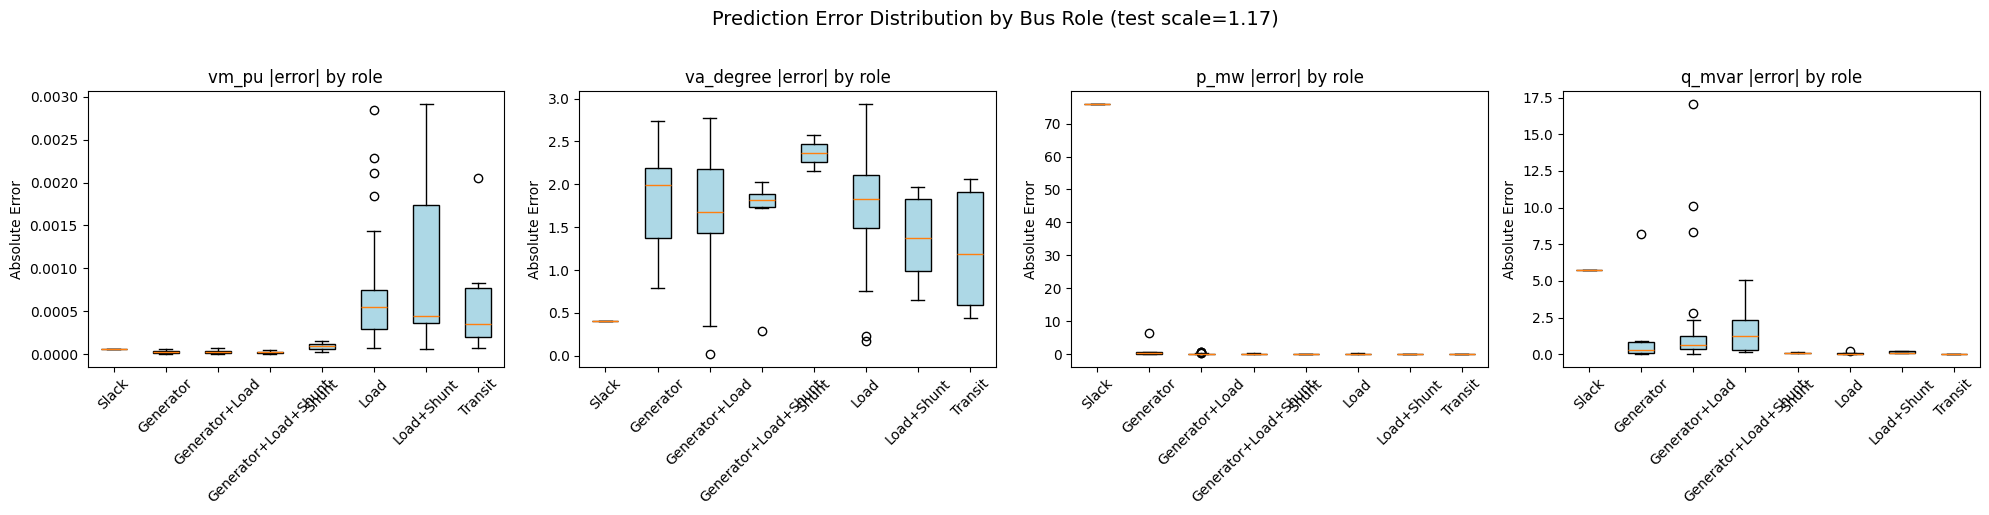

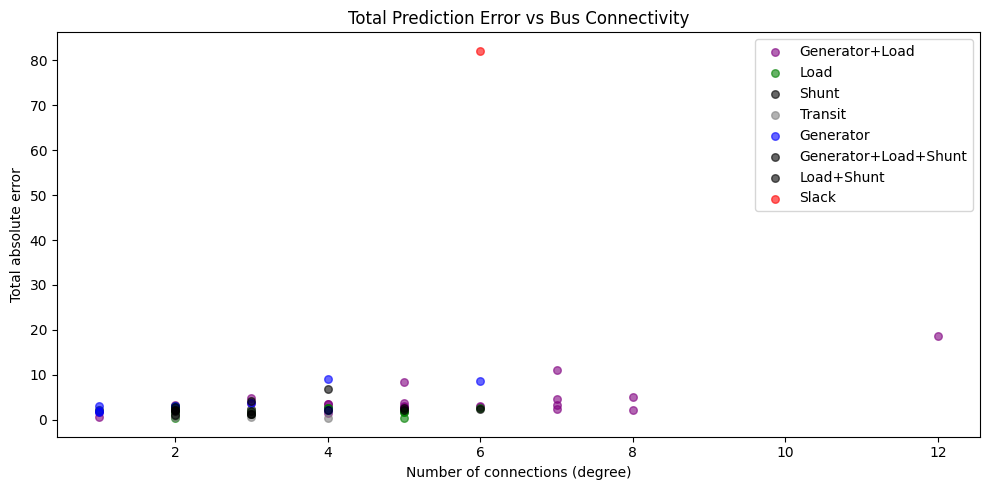

In [177]:
# === Visualize prediction error distribution by bus role ===
fig, axes = plt.subplots(1, len(target_cols), figsize=(20, 5))

roles_sorted = role_stats.index.tolist()

for i, target in enumerate(target_cols):
    ax = axes[i]
    data_by_role = [error_df[error_df['role'] == r][f'{target}_err'].values for r in roles_sorted]
    bp = ax.boxplot(data_by_role, labels=roles_sorted, vert=True, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_title(f'{target} |error| by role')
    ax.set_ylabel('Absolute Error')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Prediction Error Distribution by Bus Role (test scale={test_scale})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Scatter: total error vs number of connections ===
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Slack': 'red', 'Generator': 'blue', 'Load': 'green',
          'Generator+Load': 'purple', 'Transit': 'gray', 'Slack+Load': 'orange'}
for role in error_df['role'].unique():
    mask = error_df['role'] == role
    ax.scatter(error_df.loc[mask, 'n_connections'], error_df.loc[mask, 'total_abs_err'],
               label=role, alpha=0.6, s=30, c=colors.get(role, 'black'))
ax.set_xlabel('Number of connections (degree)')
ax.set_ylabel('Total absolute error')
ax.set_title('Total Prediction Error vs Bus Connectivity')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Why Are Some Buses Hard to Predict?

**Slack bus**: The slack (ext_grid) bus absorbs all mismatch in the system. Its active and reactive power outputs are not directly parameterized — they are *outcomes* of the PF. As load scaling changes, the slack bus response is nonlinear and hard to predict from local features alone.

**Generator (PV) buses**: Generators maintain a voltage setpoint (`vm_pu`), so voltage prediction is easier. However, their reactive power `q_mvar` is a free variable determined by the PF solver, making it harder to predict.

**High-degree (hub) buses**: Buses with many connections aggregate power flows from multiple branches. Small errors in branch flows compound, leading to larger net injection errors.

**Transit buses**: Buses with no explicit gen or load may still carry significant through-flow. Their PF solution depends entirely on the network topology and neighboring bus states, providing fewer direct features for the model.

**Shunt buses**: Shunt compensation introduces additional reactive power injection whose interaction with voltage is nonlinear.



#### OOD test
1. performance drops when testing on loading conditions out of the training condition ranges 